<a href="https://colab.research.google.com/github/Krispavnn555/NASSCOM_FDP/blob/main/DAY2_U3_Python_Part2_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# U3 — Python for AI/ML (Part 2): Lab

**The Data & ML Library Stack** — NumPy · Pandas · Matplotlib & Seaborn · scikit-learn · Data flow

_Day 2 · Phase A — Foundations · Built from Module 1.7_

#objectives

By the end of this lab you will be able to:

NumPy — create, reshape and slice arrays; use broadcasting; do matrix multiplication and axis-wise aggregation

Pandas — load a dataset, inspect it, fill missing values, and group by a category

Matplotlib & Seaborn — build subplot comparisons, correlation heatmaps and pairplots

scikit-learn — split data, train a classifier, evaluate it, and wrap it in a Pipeline

Data flow — connect every library into one end-to-end workflow: raw -> clean -> model -> output

#how to use this lab

Each section has two kinds of cells:

Worked demo cells — run them top to bottom and read the comments to learn the pattern.

LAB EXERCISE cells (marked 🧪) — your turn. Replace each `# YOUR CODE HERE` with working code.

Run cells with **Shift + Enter**. Run the demos before attempting the exercises.

In [1]:
# Core imports for the whole lab
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix

sns.set_theme(style='whitegrid')   # nicer default plot styling
np.random.seed(42)                 # reproducible results
print('Setup complete. NumPy', np.__version__, '| Pandas', pd.__version__)

Setup complete. NumPy 2.0.2 | Pandas 2.2.2


#1. NumPy — arrays & linear algebra

In [2]:
# -----------------------------------------------------------
# 🔹 1A. ARRAY CREATION & SHAPE
# -----------------------------------------------------------

# arange() builds a range; reshape() changes the shape without copying data
a = np.arange(6).reshape(2, 3)
print('Array a:\n', a)

# Inspect the array's structure
print('shape :', a.shape)     # (2, 3)  -> 2 rows, 3 cols
print('ndim  :', a.ndim)      # 2       -> number of dimensions
print('dtype :', a.dtype)     # int64   -> data type of elements

Array a:
 [[0 1 2]
 [3 4 5]]
shape : (2, 3)
ndim  : 2
dtype : int64


In [3]:
# -----------------------------------------------------------
# 🔹 1B. SLICING & INDEXING
# -----------------------------------------------------------

print('Column index 1 :', a[:, 1])        # all rows, 2nd column
print('Row index 0    :', a[0, :])        # 1st row, all columns

# Boolean mask: keep only the elements that satisfy a condition
print('Elements > 2   :', a[a > 2])

Column index 1 : [1 4]
Row index 0    : [0 1 2]
Elements > 2   : [3 4 5]


In [4]:
# -----------------------------------------------------------
# 🔹 1C. BROADCASTING
# -----------------------------------------------------------

# Broadcasting lets NumPy combine arrays of different shapes without loops
row = np.array([10, 20, 30])   # shape (3,)
print('a + row (row added to every row of a):\n', a + row)

a + row (row added to every row of a):
 [[10 21 32]
 [13 24 35]]


In [5]:
# -----------------------------------------------------------
# 🔹 1D. MATRIX MULTIPLICATION + AXIS-WISE OPERATIONS  (core demo)
# -----------------------------------------------------------

b = np.ones((3, 2), dtype=int)   # shape (3, 2)
print('Matrix product a @ b:\n', a @ b)   # (2,3) @ (3,2) -> (2,2)

# Axis-wise reductions: axis=0 collapses rows, axis=1 collapses columns
print('Column-wise sum  (axis=0):', a.sum(axis=0))
print('Row-wise sum     (axis=1):', a.sum(axis=1))
print('Row-wise mean    (axis=1):', a.mean(axis=1))
print('Index of max per column  :', a.argmax(axis=0))

Matrix product a @ b:
 [[ 3  3]
 [12 12]]
Column-wise sum  (axis=0): [3 5 7]
Row-wise sum     (axis=1): [ 3 12]
Row-wise mean    (axis=1): [1. 4.]
Index of max per column  : [1 1 1]


#### 🧪 LAB EXERCISE 1 — Matrix multiplication + axis-wise operations

Using the 2-D array `M` provided below:
1. Multiply `M` by `N` with the `@` operator and print the result.
2. Print the **column-wise sum** and the **row-wise mean** of `M`.
3. Print the index of the maximum value in **each row** of `M`.

In [6]:
M = np.arange(1, 13).reshape(3, 4)   # shape (3, 4)
N = np.arange(1, 9).reshape(4, 2)    # shape (4, 2)
print('M:\n', M)
print('N:\n', N)

# 1. Matrix product M @ N
print('Matrix product M @ N:\n', M @ N)

# 2. Column-wise sum (axis=0) and row-wise mean (axis=1) of M
print('Column-wise sum of M (axis=0):', M.sum(axis=0))
print('Row-wise mean of M (axis=1):', M.mean(axis=1))

# 3. Index of the max value in each row of M (hint: argmax with axis=1)
print('Index of max per row of M (axis=1):', M.argmax(axis=1))

M:
 [[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
N:
 [[1 2]
 [3 4]
 [5 6]
 [7 8]]
Matrix product M @ N:
 [[ 50  60]
 [114 140]
 [178 220]]
Column-wise sum of M (axis=0): [15 18 21 24]
Row-wise mean of M (axis=1): [ 2.5  6.5 10.5]
Index of max per row of M (axis=1): [3 3 3]


#2. Pandas — load, clean & group

In [7]:
# -----------------------------------------------------------
# 🔹 2A. LOAD & INSPECT
# -----------------------------------------------------------

# Load the classic Titanic dataset (built into seaborn).
# In your own work this would be: pd.read_csv('titanic.csv')
df = sns.load_dataset('titanic')

print('Shape:', df.shape)
df.head()

Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [8]:
# .info() shows columns, dtypes and non-null counts -> spot missing data fast
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [9]:
# .describe() gives summary statistics for the numeric columns
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [10]:
# -----------------------------------------------------------
# 🔹 2B. HANDLE MISSING VALUES
# -----------------------------------------------------------

# Count missing values per column
print('Missing values per column:')
print(df.isna().sum().sort_values(ascending=False).head())

# Fill missing 'age' with the median (a common, robust strategy)
df['age'] = df['age'].fillna(df['age'].median())
print('\nMissing ages after fillna:', df['age'].isna().sum())

Missing values per column:
deck           688
age            177
embarked         2
embark_town      2
sex              0
dtype: int64

Missing ages after fillna: 0


In [11]:
# -----------------------------------------------------------
# 🔹 2C. GROUP BY A CATEGORY  (split -> apply -> combine)
# -----------------------------------------------------------

# Average survival rate by passenger class
print('Survival rate by class:')
print(df.groupby('class', observed=True)['survived'].mean())

# Two-level grouping: survival by class AND sex
print('\nSurvival rate by class and sex:')
print(df.groupby(['class', 'sex'], observed=True)['survived'].mean())

Survival rate by class:
class
First     0.629630
Second    0.472826
Third     0.242363
Name: survived, dtype: float64

Survival rate by class and sex:
class   sex   
First   female    0.968085
        male      0.368852
Second  female    0.921053
        male      0.157407
Third   female    0.500000
        male      0.135447
Name: survived, dtype: float64


#### 🧪 LAB EXERCISE 2 — Load, fill missing values, group by category

Work on a fresh copy of the Titanic data (`lab`):
1. Print how many values are missing in the **`embarked`** column.
2. Fill the missing `embarked` values with the most frequent value (the *mode*).
3. Group by **`sex`** and print the **mean `fare`** paid by each group.

In [13]:
lab = sns.load_dataset('titanic')   # fresh copy to work on

# 1. Count missing values in 'embarked'
print("Missing values in 'embarked':", lab['embarked'].isna().sum())

# 2. Fill missing 'embarked' with the mode (hint: lab['embarked'].mode()[0])
mode_embarked = lab['embarked'].mode()[0]
lab['embarked'] = lab['embarked'].fillna(mode_embarked)
print("Missing 'embarked' after fillna:", lab['embarked'].isna().sum())

# 3. Mean fare grouped by 'sex'
print('\nMean fare grouped by sex:')
print(lab.groupby('sex')['fare'].mean())

Missing values in 'embarked': 2
Missing 'embarked' after fillna: 0

Mean fare grouped by sex:
sex
female    44.479818
male      25.523893
Name: fare, dtype: float64


#3. Matplotlib & Seaborn — visualize

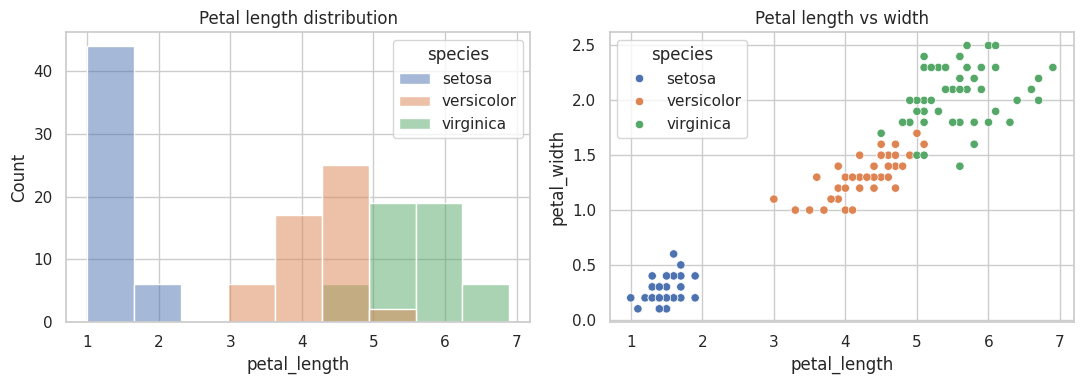

In [14]:
# -----------------------------------------------------------
# 🔹 3A. SUBPLOT COMPARISON  (Matplotlib)
# -----------------------------------------------------------

iris = sns.load_dataset('iris')   # 150 flowers, 4 measurements, 3 species

# plt.subplots() makes a grid of axes for side-by-side charts
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.histplot(data=iris, x='petal_length', hue='species', ax=axes[0])
axes[0].set_title('Petal length distribution')

sns.scatterplot(data=iris, x='petal_length', y='petal_width',
                hue='species', ax=axes[1])
axes[1].set_title('Petal length vs width')

plt.tight_layout()
plt.show()

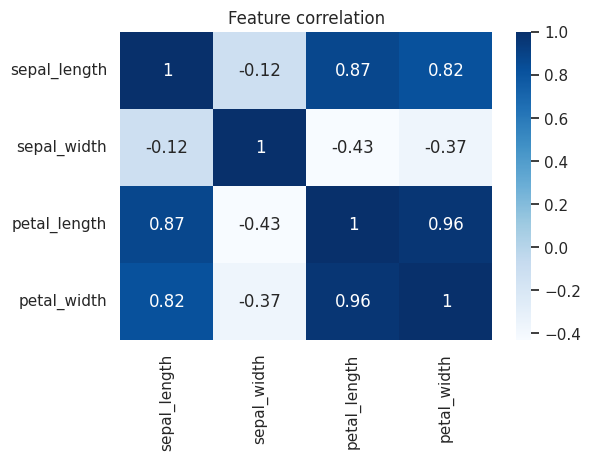

In [15]:
# -----------------------------------------------------------
# 🔹 3B. CORRELATION HEATMAP  (Seaborn)
# -----------------------------------------------------------

# .corr() on the numeric columns, visualised as a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(iris.drop(columns='species').corr(),
            annot=True, cmap='Blues')
plt.title('Feature correlation')
plt.show()

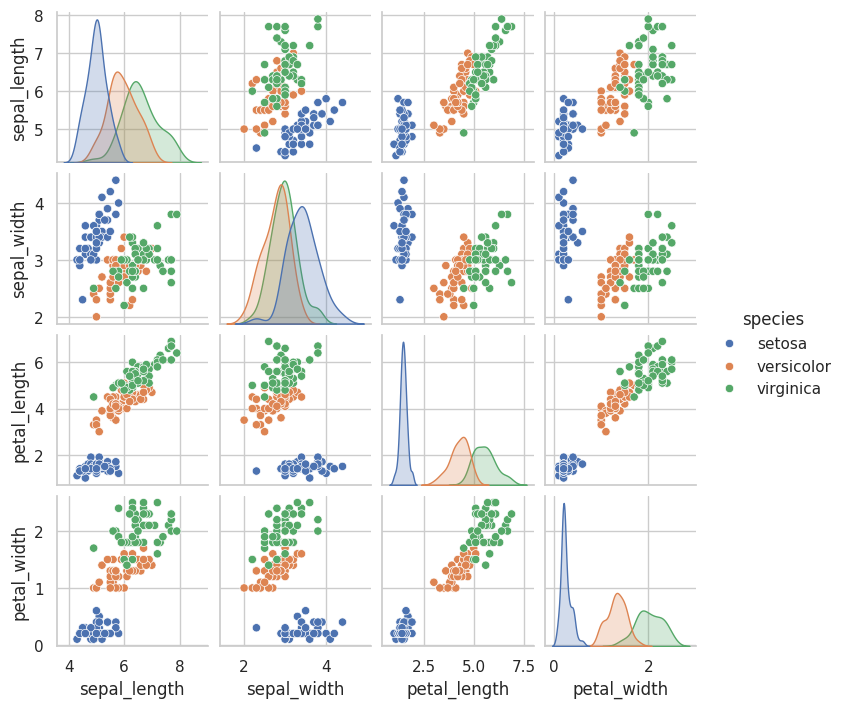

In [16]:
# -----------------------------------------------------------
# 🔹 3C. PAIRPLOT  (every feature vs every feature)
# -----------------------------------------------------------

# A pairplot draws scatter plots for all feature pairs at once,
# coloured by class -> a fast way to see how separable the classes are.
sns.pairplot(iris, hue='species', height=1.8)
plt.show()

#### 🧪 LAB EXERCISE 3 — Pairplot + subplot comparison

Use the **penguins** dataset loaded below:
1. Drop rows with missing values using `.dropna()`.
2. Build a **pairplot** of the penguins coloured by `species`.
3. Create a `1 x 2` **subplot**: a boxplot of `body_mass_g` by `species` on the left, and a scatter of `bill_length_mm` vs `flipper_length_mm` on the right.

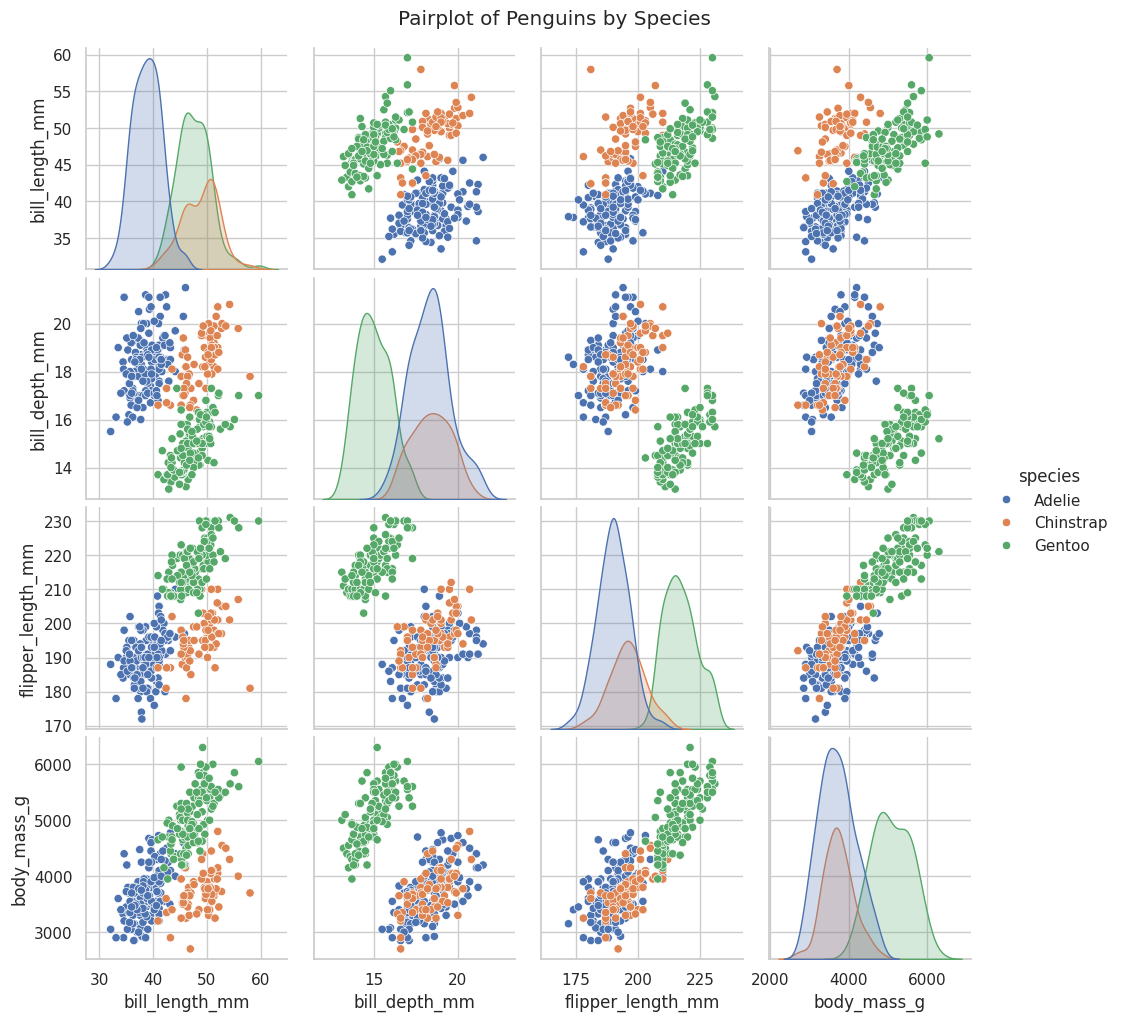

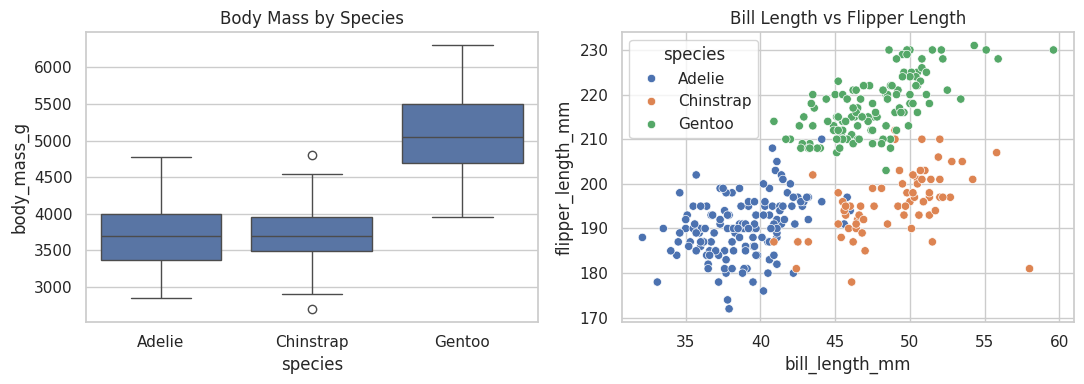

In [17]:
pen = sns.load_dataset('penguins')

# 1. Drop rows with missing values
pen = pen.dropna()

# 2. Pairplot coloured by 'species'
sns.pairplot(pen, hue='species')
plt.suptitle('Pairplot of Penguins by Species', y=1.02) # Add a title above the pairplot
plt.show()

# 3. 1x2 subplot: boxplot (left) + scatter (right)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.boxplot(data=pen, x='species', y='body_mass_g', ax=axes[0])
axes[0].set_title('Body Mass by Species')

sns.scatterplot(data=pen, x='bill_length_mm', y='flipper_length_mm', hue='species', ax=axes[1])
axes[1].set_title('Bill Length vs Flipper Length')

plt.tight_layout()
plt.show()

#4. scikit-learn — your first model

In [18]:
# -----------------------------------------------------------
# 🔹 4A. LOAD DATA & SPLIT
# -----------------------------------------------------------

# Load iris as feature matrix X and target vector y
X, y = load_iris(return_X_y=True)
print('Features X:', X.shape, '| Target y:', y.shape)

# Hold out 20% of the data for testing. stratify keeps class balance.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print('Train:', X_train.shape[0], 'samples | Test:', X_test.shape[0], 'samples')

Features X: (150, 4) | Target y: (150,)
Train: 120 samples | Test: 30 samples


In [ ]:
# -----------------------------------------------------------
# 🔹 4B. FIT -> PREDICT -> EVALUATE  (the estimator API)
# -----------------------------------------------------------

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)               # learn from training data
pred = clf.predict(X_test)              # score new samples

print('Accuracy:', round(accuracy_score(y_test, pred), 3))
print('Confusion matrix:\n', confusion_matrix(y_test, pred))

In [20]:
# -----------------------------------------------------------
# 🔹 4C. PIPELINE  (preprocessing + model as one object)
# -----------------------------------------------------------

# A Pipeline chains steps so the SAME transform runs on train and test
# data -> no leakage, and a single .fit() / .predict() call.
pipe = Pipeline([
    ('scaler', StandardScaler()),               # step 1: scale features
    ('model', LogisticRegression(max_iter=200)) # step 2: classify
])

pipe.fit(X_train, y_train)
print('Pipeline accuracy:', round(pipe.score(X_test, y_test), 3))

Pipeline accuracy: 0.933


#### 🧪 LAB EXERCISE 4 — Train a classifier & evaluate via a Pipeline

Using the **breast cancer** dataset loaded below:
1. Split it into train/test sets (use `test_size=0.25`, `random_state=0`, `stratify=yb`).
2. Build a `Pipeline` of `StandardScaler` + a classifier of your choice.
3. Fit it and print the **test accuracy** with `pipe.score(...)`.

In [21]:
Xb, yb = load_breast_cancer(return_X_y=True)
print('Breast cancer data:', Xb.shape)

# 1. train_test_split
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    Xb, yb, test_size=0.25, random_state=0, stratify=yb)
print(f'Train: {Xb_train.shape[0]} samples | Test: {Xb_test.shape[0]} samples')

# 2. Build a Pipeline (StandardScaler + a classifier)
pipe_bc = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(random_state=0)) # Using RandomForestClassifier as an example
])

# 3. Fit and print the test accuracy
pipe_bc.fit(Xb_train, yb_train)
print('Pipeline test accuracy:', round(pipe_bc.score(Xb_test, yb_test), 3))

Breast cancer data: (569, 30)
Train: 426 samples | Test: 143 samples
Pipeline test accuracy: 0.944


#5. Putting it together — data flow: raw -> clean -> model -> output

Every library you just learned has one job in the pipeline. The cell below runs the whole stack end-to-end on the Titanic data.

End-to-end Titanic survival accuracy: 0.793


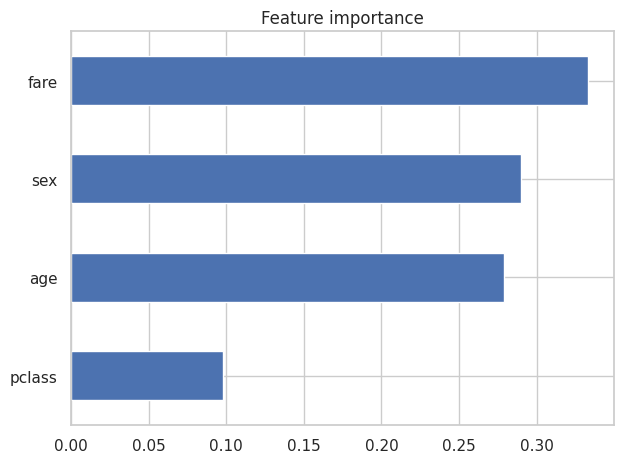

In [22]:
# -----------------------------------------------------------
# 🔹 5. END-TO-END MINI WORKFLOW
# -----------------------------------------------------------

# RAW  -> load the table (Pandas)
data = sns.load_dataset('titanic')

# CLEAN -> keep a few features, fill/drop missing, encode 'sex' (Pandas + NumPy)
data = data[['survived', 'pclass', 'sex', 'age', 'fare']].copy()
data['age'] = data['age'].fillna(data['age'].median())
data['sex'] = np.where(data['sex'] == 'male', 0, 1)   # encode to numbers
data = data.dropna()

# SPLIT -> features X and target y as NumPy arrays (NumPy)
X = data.drop(columns='survived').values
y = data['survived'].values
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

# MODEL -> fit + predict + score (scikit-learn)
model = RandomForestClassifier(random_state=42).fit(X_tr, y_tr)
acc = accuracy_score(y_te, model.predict(X_te))

# OUTPUT -> the result, plus a quick feature-importance chart (Matplotlib)
print('End-to-end Titanic survival accuracy:', round(acc, 3))

importances = pd.Series(model.feature_importances_,
                        index=data.drop(columns='survived').columns)
importances.sort_values().plot.barh(title='Feature importance')
plt.tight_layout(); plt.show()

#### 🧪 LAB EXERCISE 5 — Build your own end-to-end flow

Reproduce the **raw -> clean -> split -> model -> output** flow on the iris dataset:
1. Load iris into a DataFrame (`sns.load_dataset('iris')`).
2. Separate features `X` and target `species`; encode the target to numbers.
3. Split, train any classifier, and print the test accuracy.

_Tip: reuse the patterns from the demo cell above._

In [24]:
# 1. load   2. clean/encode   3. split   4. model   5. output (print accuracy)

# RAW -> load the dataset (Pandas)
iris_df = sns.load_dataset('iris')

# CLEAN / ENCODE -> Separate features X and target y; encode species to numbers
# The 'species' column is already categorical, let's map it to numerical values
iris_df['species_encoded'] = iris_df['species'].astype('category').cat.codes
X_iris = iris_df.drop(columns=['species', 'species_encoded']).values
y_iris = iris_df['species_encoded'].values

# SPLIT -> features X and target y into train/test sets (NumPy)
X_iris_tr, X_iris_te, y_iris_tr, y_iris_te = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris)

# MODEL -> fit + predict + score (scikit-learn)
iris_model = RandomForestClassifier(random_state=42)
iris_model.fit(X_iris_tr, y_iris_tr)
iris_acc = accuracy_score(y_iris_te, iris_model.predict(X_iris_te))

# OUTPUT -> the result (print accuracy)
print('End-to-end Iris classification accuracy:', round(iris_acc, 3))

End-to-end Iris classification accuracy: 0.9


#📘 Summary — the Part 2 toolkit

| Library | What it does | Key calls you used |
| ------- | ------------ | ------------------ |
| **NumPy** | Fast array math, the substrate for all ML | `reshape`, `@`, `sum(axis=)`, masks |
| **Pandas** | Load & clean tabular data | `read_csv`, `fillna`, `groupby`, `dropna` |
| **Matplotlib / Seaborn** | See the data | `subplots`, `heatmap`, `pairplot` |
| **scikit-learn** | Train & evaluate models | `train_test_split`, `fit`, `predict`, `Pipeline` |
| **Data flow** | Connect it all | raw -> clean -> split -> model -> output |

**Homework (self-paced):** tensor ops & cosine similarity in NumPy · clean a CSV + groupby in Pandas · a pairplot + subplot comparison · train one classifier through a Pipeline.

